In [3]:
import timeit
from ppg_basis import ppgGenerator
from ppg_constants import basis_types, default_M
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Disabling robustBufferAccess2 and robustImageAccess2: IntegratedGpu Intel Driver is outdated. Found with version 0x1947CF, less than the known good version 0x194843 (31.0.101.2115)
Disabling robustBufferAccess2 and robustImageAccess2: IntegratedGpu Intel Driver is outdated. Found with version 0x1947CF, less than the known good version 0x194843 (31.0.101.2115)
Disabling robustBufferAccess2 and robustImageAccess2: IntegratedGpu Intel Driver is outdated. Found with version 0x1947CF, less than the known good version 0x194843 (31.0.101.2115)
Disabling robustBufferAccess2 and robustImageAccess2: IntegratedGpu Intel Driver is outdated. Found with version 0x1947CF, less than the known good version 0x194843 (31.0.101.2115)
Disabling robustBufferAccess2 and robustImageAccess2: IntegratedGpu Intel Driver is outdated. Found with version 0x1947CF, less than the known good version 0x194843 (31.0.101.2115)


Available devices:
🯄 (default) | Intel(R) Iris(R) Plus Graphics | IntegratedGPU | Vulkan | Intel driver
🯄 | Intel(R) Iris(R) Plus Graphics | IntegratedGPU | D3D12 | 
❗ | Microsoft Basic Render Driver | CPU | D3D12 | 
❗ | Intel(R) Iris(R) Plus Graphics | IntegratedGPU | OpenGL | 


In [ ]:
# constants

Ls = [2, 3, 4, 5, 10]

def gen_pipeline(duration: int, L: int, basis_type: str, solver: str, M: int):
    ppgGen = ppgGenerator(fs=125,
                          hr=60,
                          mu=0.85,
                          sigma=0.05,
                          duration=duration,
                          L= L,
                          basis_type=basis_type,
                          solver = solver)
    return ppgGen.generate_signal(M)

num_times = 150

durations = [10, 25, 50, 75, 100, 250, 500, 750, 1000]

methods = ["Template", "FFT"]

Ms = [64, 128, 256, 512, 1024]

bar_width = 0.35  
x_positions = np.arange(len(Ls))

line_styles = ["--", "-"]
Ls_colors = plt.cm.rainbow(np.linspace(0, 1, len(Ls)))
fft_template_colors = [
    "#a6cee3", "#33a0c9", "#1f78b4", "#1c5a7e", "#0f3b4d",
    "#fdbf6f", "#ff9933", "#ff7f00", "#b35a00", "#663300"
]


# ODE vs BASE Analysis

In [ ]:
def ode_vs_base_analysis(duration: int):
    """
    Returns an array containing:
    [
        [
            RK3_base for gaussian,
            RK4_base for gaussian
        ],
        [
            RK3_base for gamma,
            RK4_base for gamma
        ],
        [
            RK3_base for skewed-gaussian,
            RK4_base for skewed-gaussian
        ]
    ]
    """
    toReturn = []
    for basis_type in basis_types:
        RK3_base = []
        RK4_base = []
        for L in Ls:
            RK3_time = timeit.timeit(lambda : gen_pipeline(duration, L, basis_type, "rk3", default_M), number = num_times)
            RK4_time = timeit.timeit(lambda : gen_pipeline(duration, L, basis_type, "rk4", default_M), number = num_times)
            base_time = timeit.timeit(lambda : gen_pipeline(duration, L, basis_type, "basis", default_M), number = num_times)
            RK3_base.append(RK3_time / base_time)
            RK4_base.append(RK4_time / base_time)
        toReturn.append((RK3_base, RK4_base))
    return toReturn

top_pipeline_values = ode_vs_base_analysis(10)

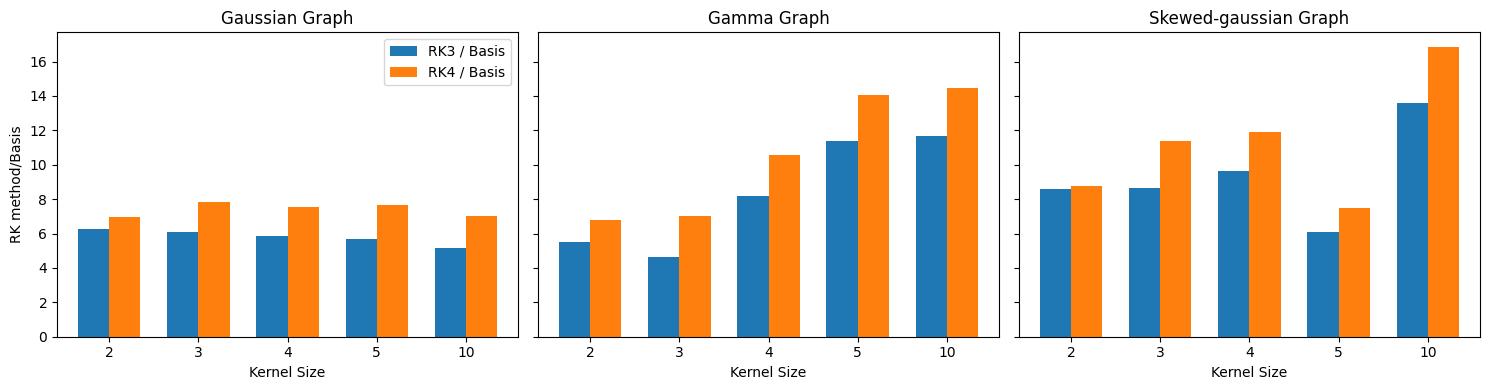

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, ax in enumerate(axes):
    y1 = top_pipeline_values[i][0]
    y2 = top_pipeline_values[i][1]

    ax.bar(x_positions - bar_width/2, y1, width=bar_width, label="RK3 / Basis")
    ax.bar(x_positions + bar_width/2, y2, width=bar_width, label="RK4 / Basis")

    ax.set_xticks(x_positions)
    ax.set_xticklabels(Ls)
    ax.set_title(f"{basis_types[i].capitalize()} Graph")
    ax.set_xlabel("Kernel Size")

axes[0].set_ylabel("RK method/Basis")
axes[0].legend()

plt.tight_layout()
plt.show()

# FFT & TEMPLATE vs BASE Analysis

In [ ]:
def fft_template_vs_base_analysis(basis_type: str):
    """
    given a basis_type (a graph in row 2), returns an array of the following:
    [
        [ # template_arr
            [ L = 2
                template_time / base_time for duration = 10, 25, ...
            ],
            [ L = 3
                template_time / base_time for duration = 10, 25, ...
            ],
            [ L = ...
                template_time / base_time for duration = 10, 25, ...
            ]
        ],
        [ # fft_arr
            [ L = 2
                template_time / base_time for duration = 10, 25, ...
            ],
            [ L = 3
                template_time / base_time for duration = 10, 25, ...
            ],
            [ L = ...
                template_time / base_time for duration = 10, 25, ...
            ]
        ]
    ]
    """
    template_arr = []
    fft_arr = []
    # print(f"Beginning {basis_type} analysis")
    for L in Ls:
        L_template = []
        L_fft = []
        # print(f"Beginning {basis_type} for kernel size {L}")
        for duration in durations:
            # print(f"Beginning {basis_type} for kernel size {L} for duration {duration}")
            template_time = timeit.timeit(lambda : gen_pipeline(duration, L, basis_type, 'template', default_M), number = num_times)
            fft_time = timeit.timeit(lambda : gen_pipeline(duration, L, basis_type, 'fft', default_M), number = num_times)
            base_time = timeit.timeit(lambda : gen_pipeline(duration, L, basis_type, 'basis', default_M), number = num_times)
            L_template.append(template_time / base_time)
            L_fft.append(fft_time / base_time)
            # print(f"Ending {basis_type} for kernel size {L} for duration {duration}")
        template_arr.append(L_template)
        fft_arr.append(L_fft)
        # print(f"Ended {basis_type} for kernel size {L}")
    return [template_arr, fft_arr]

gaussian_template_fft = fft_template_vs_base_analysis('gaussian')
gamma_template_fft = fft_template_vs_base_analysis('gamma')
skewed_gaussian_template_fft = fft_template_vs_base_analysis('skewed-gaussian')

Beginning gaussian analysis
Beginning gaussian for kernel size 2
Beginning gaussian for kernel size 2 for duration 10
Ending gaussian for kernel size 2 for duration 10
Beginning gaussian for kernel size 2 for duration 25
Ending gaussian for kernel size 2 for duration 25
Beginning gaussian for kernel size 2 for duration 50
Ending gaussian for kernel size 2 for duration 50
Beginning gaussian for kernel size 2 for duration 75
Ending gaussian for kernel size 2 for duration 75
Beginning gaussian for kernel size 2 for duration 100
Ending gaussian for kernel size 2 for duration 100
Beginning gaussian for kernel size 2 for duration 250
Ending gaussian for kernel size 2 for duration 250
Beginning gaussian for kernel size 2 for duration 500
Ending gaussian for kernel size 2 for duration 500
Beginning gaussian for kernel size 2 for duration 750
Ending gaussian for kernel size 2 for duration 750
Beginning gaussian for kernel size 2 for duration 1000
Ending gaussian for kernel size 2 for duration 1

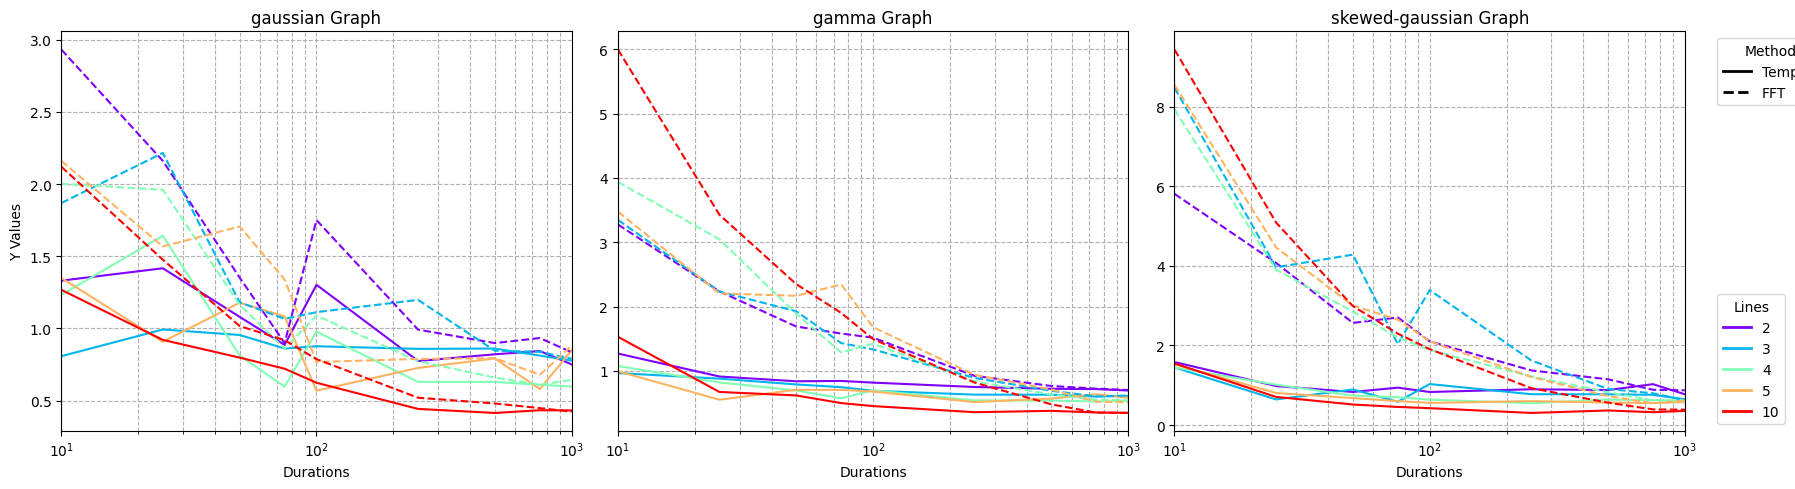

In [34]:
fft_template_vs_base_data = [gaussian_template_fft, gamma_template_fft, skewed_gaussian_template_fft]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, data, basis_type in zip(axes, fft_template_vs_base_data, basis_types):
    # Plot all lines
    for method_idx, method_lines in enumerate(data):
        for line_idx, y_values in enumerate(method_lines):
            ax.plot(durations, y_values,
                    linestyle=line_styles[method_idx],
                    color=Ls_colors[line_idx])

    ax.set_xscale("log")
    ax.set_xlim(10, 1000)
    ax.set_xlabel("Durations")
    ax.set_title(f"{basis_type} Graph")
    ax.grid(True, which="both", ls="--")

# Only first subplot gets y-axis label
axes[0].set_ylabel("Y Values")

# Legends outside figure
method_handles = [Line2D([0], [0], color='black', linestyle=ls, lw=2) for ls in line_styles]
legend1 = axes[2].legend(method_handles, methods, title="Methods",
                          loc='upper left', bbox_to_anchor=(1.05, 1))
axes[2].add_artist(legend1)

Ls_handles = [Line2D([0], [0], color=Ls_colors[i], lw=2) for i in range(len(Ls))]
axes[2].legend(Ls_handles, Ls, title="Lines", loc='lower left', bbox_to_anchor=(1.05, 0))

plt.tight_layout()
plt.show()

# FFT & TEMPLATE vs ODE/RK Analysis

In [ ]:
# compare fft & template to rk4 with differing values of M to compare accuracy
# to do this, we want to do (fft_time / base_time) - (rk4_time / base_time) and then multiply by base_time
def fft_template_accuracy_comparison(duration: int):
    '''
    At the end, we have the following array
    [
        basis types
        [
            kernel sizes
            [
                fft - rk4
                template - rk4
            ]
            ...
        ]
        ...
    ]
    '''
    toReturn = []
    for basis_type in basis_types:
        basis_type_arr = []
        for L in Ls:
            L_arr = []
            for M in Ms:
                RK4 = gen_pipeline(duration, L, basis_type, "rk4", M)
                fft = gen_pipeline(duration, L, basis_type, "fft", M)
                template = gen_pipeline(duration, L, basis_type, "template", M)
                L_arr.append(fft - RK4)
                L_arr.append(template - RK4)
            basis_type_arr.append(L_arr)
        toReturn.append(basis_type_arr)
    return toReturn

fft_template_accuracy_data = np.array(fft_template_accuracy_comparison(10))

array([[[[-4.88539056e-01, -4.97222466e-01, -5.04644942e-01, ...,
          -6.17326265e-01, -6.48991357e-01, -6.81433465e-01],
         [-2.34333924e-01, -1.90196702e-01, -1.45438055e-01, ...,
           2.80953259e-02,  2.20441021e-02,  1.41379074e-02],
         [ 6.71128076e-01,  6.91319523e-01,  7.09961986e-01, ...,
          -7.22444620e-01, -6.94388377e-01, -6.64799195e-01],
         ...,
         [-5.76669016e-01, -6.05526017e-01, -6.33262258e-01, ...,
           8.85839536e-02,  8.52693262e-02,  8.17650197e-02],
         [ 2.04899379e-01,  1.98439427e-01,  1.90443747e-01, ...,
          -6.90914707e-01, -6.46262797e-01, -6.01701351e-01],
         [ 3.58924922e-01,  3.89197989e-01,  4.19115361e-01, ...,
          -2.35569761e-01, -2.25662695e-01, -2.14283863e-01]],

        [[-1.34898000e-01, -1.70131201e-01, -2.22005750e-01, ...,
           6.88963458e-01,  6.99575215e-01,  7.07261520e-01],
         [ 1.52975528e-01,  1.50472606e-01,  1.29366433e-01, ...,
           7.71770338e

3 5 10 1250


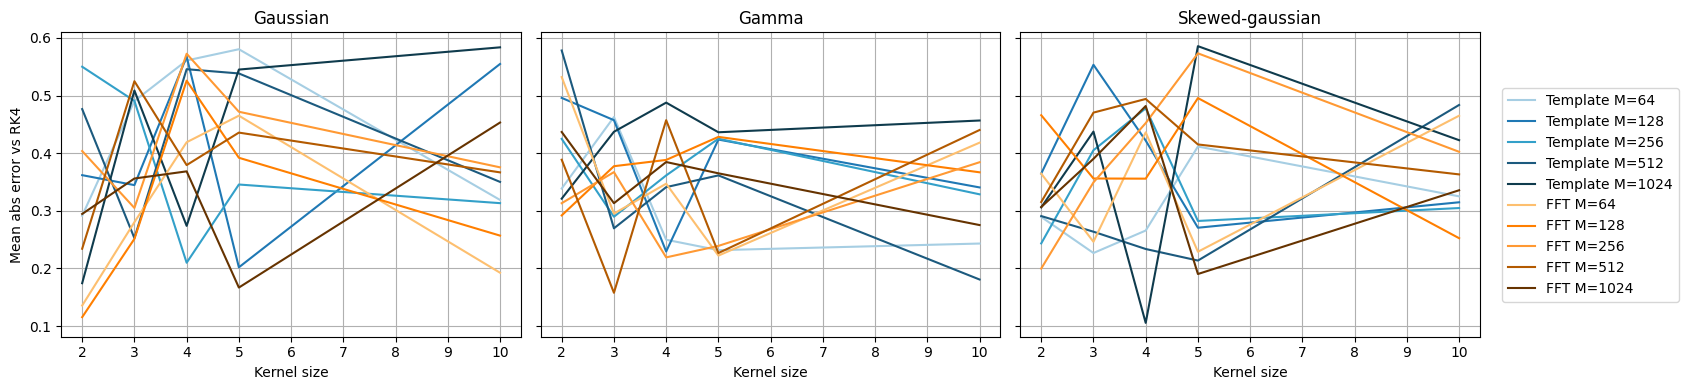

In [19]:
num_basis, num_kernels, num_methods, signal_len = fft_template_accuracy_data.shape

print(num_basis, num_kernels, num_methods, signal_len)

errors = np.abs(fft_template_accuracy_data).mean(axis=-1) # mean abs error, do we want to do a different error comparison?

fig, axes = plt.subplots(1, num_basis, figsize=(15, 4), sharey=True)
for b in range(num_basis):
    ax = axes[b]
    for m, method in enumerate(methods):
        for i, M in enumerate(Ms):
            idx = m * len(Ms) + i
            ax.plot(Ls, errors[b, :, idx],
                    color=fft_template_colors[idx],
                    label=f"{method} M={M}")
    ax.set_title(f"{basis_types[b].capitalize()}")
    ax.set_xlabel("Kernel size")
    if b == 0:
        ax.set_ylabel("Mean abs error vs RK4")
    ax.grid(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()
